In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
df = pd.read_csv("cleaned_child_malnutrition_data.csv")


In [ ]:
df.head()

,Country Name,Year,"Literacy rate, adult female (% of females ages 15 and above)",Pregnant women receiving prenatal care (%),"Prevalence of stunting, height for age (% of children under 5)",Region_Type
0,Afghanistan,2004,73.372808,85.757125,59.3,1
1,Afghanistan,2013,73.372808,85.757125,40.4,0
2,Afghanistan,2018,73.372808,65.200000,38.2,0
3,Afghanistan,2022,26.600000,85.757125,44.6,1
4,Albania,2005,73.372808,97.100000,26.7,0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 845 entries, 0 to 844
Data columns (total 6 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   Country Name                                                    845 non-null    int64  
 1   Year                                                            845 non-null    int64  
 2   Literacy rate, adult female (% of females ages 15 and above)    845 non-null    float64
 3   Pregnant women receiving prenatal care (%)                      845 non-null    float64
 4   Prevalence of stunting, height for age (% of children under 5)  845 non-null    float64
 5   Region_Type                                                     845 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 39.7 KB


In [24]:
#handel missing values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [23]:
#convert data into number
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [22]:
target = "Prevalence of stunting, height for age (% of children under 5)"

X = df.drop(columns=[target])
y = df[target]

In [ ]:
#split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
#train decison tree regresion model
model = DecisionTreeRegressor(random_state=42)

model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [20]:
#prediction
pred = model.predict(X_test)

In [19]:
print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MAE: 7.0727810650887575
R2 Score: 0.47462017637887555


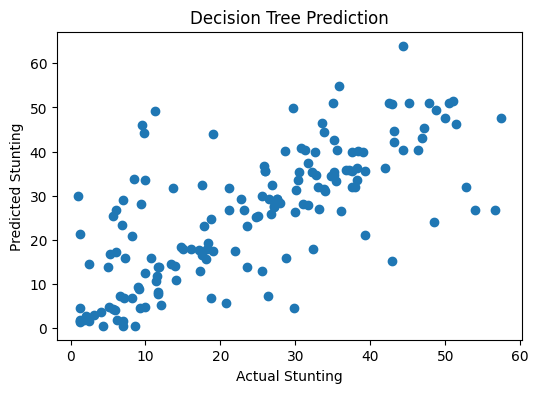

In [18]:
#actual vs prediction vales
plt.figure(figsize=(6,4))
plt.scatter(y_test, pred)
plt.xlabel("Actual Stunting")
plt.ylabel("Predicted Stunting")
plt.title("Decision Tree Prediction")
plt.show()

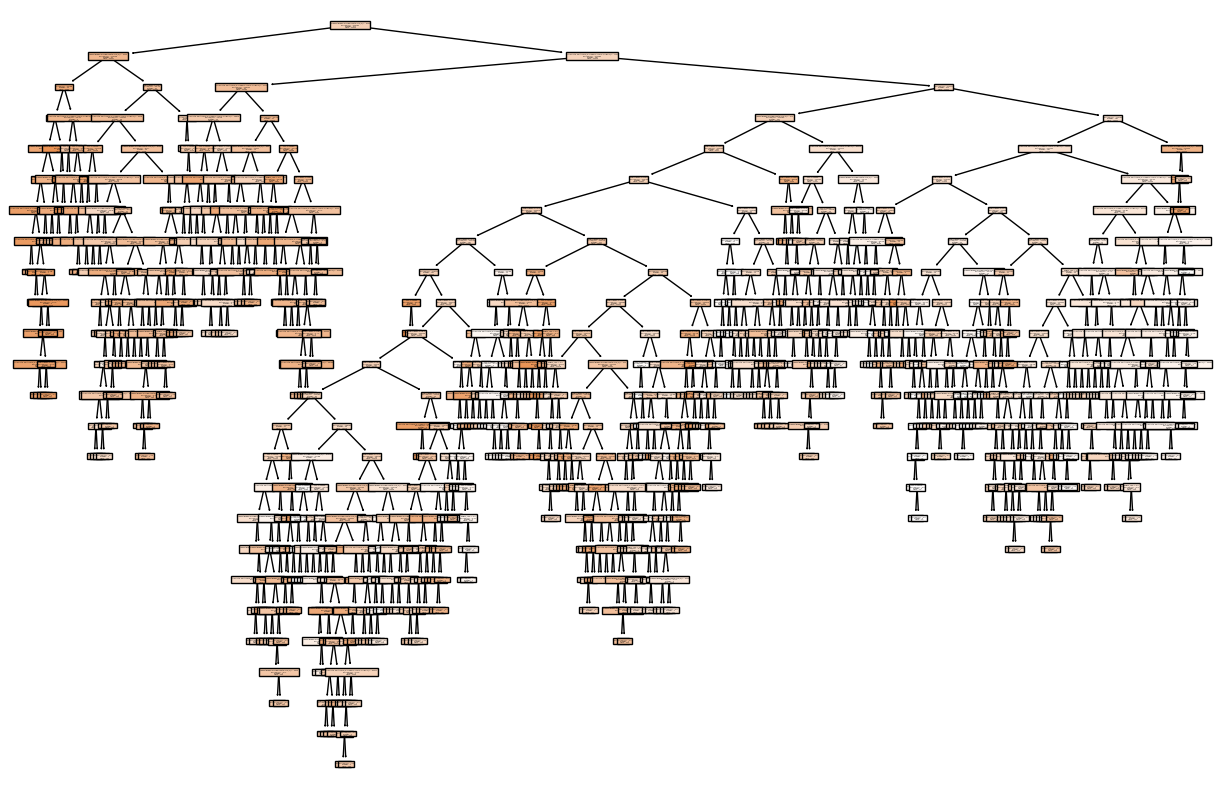

In [17]:
#Visualize Decision Tree
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(model, filled=True, feature_names=X.columns)
plt.show()